# AEMO Data Ingestion and Exploration

This notebook demonstrates the use of the `aemo_data` module for fetching and analyzing Australian Energy Market Operator (AEMO) datasets.

## Data Sources

The AEMO data module provides access to:
- **Energy Prices**: Regional Reference Price (RRP) and total demand at 5-minute intervals
- **FCAS Prices**: Frequency Control Ancillary Services prices for maintaining grid stability
- **Generation Mix**: Power output by fuel type (solar, wind, coal, gas, etc.)

### Public Data Sources

AEMO publishes market data through:
- **NEMWEB**: http://nemweb.com.au/ - Historical market data archive
- **MMS Data Model**: Detailed pricing and generation records

### Limitations

- Data is provided at 5-minute dispatch intervals
- Historical data may have gaps or quality issues
- Synthetic data is used in this demo for illustration purposes
- Real AEMO data requires proper parsing of CSV/ZIP archives from NEMWEB

In [1]:
import sys
sys.path.append('src')

from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

from aemo_data import (
    fetch_aemo_dispatch_price,
    fetch_aemo_fcas_price,
    fetch_aemo_generation_by_fuel,
    fetch_aemo_data_bundle,
    AEMO_REGIONS,
    FCAS_SERVICES,
)

In [2]:
print(AEMO_REGIONS)

['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']


In [3]:
print(FCAS_SERVICES)

['RAISE6SEC', 'LOWER6SEC', 'RAISE60SEC', 'LOWER60SEC', 'RAISE5MIN', 'LOWER5MIN', 'RAISEREG', 'LOWERREG']


## 1. Fetch a Short Date Range

Let's start by fetching 2 days of data for NSW1 region.

In [4]:
# Define date range
# pick some dates in 2023
end_date = datetime(2023, 3, 15)
start_date = end_date - timedelta(days=2)
region = AEMO_REGIONS[1]
print(f"Fetching data from {start_date.date()} to {end_date.date()}")
print(f"Region: {region}")

Fetching data from 2023-03-13 to 2023-03-15
Region: QLD1


### Fetch Energy Prices

In [5]:
# Fetch dispatch prices
prices = fetch_aemo_dispatch_price(
    start_date=start_date,
    end_date=end_date,
    region=region
)

print(f"\nFetched {len(prices)} price records")
print("\nSample data:")
print(prices.head())

print("\nPrice statistics:")
print(prices.select(["RRP", "TOTALDEMAND"]).describe())

Fetching dispatch price data for QLD1 from 2023-03-13 to 2023-03-15...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 576 price records

Fetched 576 price records

Sample data:
shape: (5, 4)
┌─────────────────────┬──────────┬──────────┬─────────────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ RRP      ┆ TOTALDEMAND │
│ ---                 ┆ ---      ┆ ---      ┆ ---         │
│ datetime[ns]        ┆ str      ┆ f64      ┆ f64         │
╞═════════════════════╪══════════╪══════════╪═════════════╡
│ 2023-03-13 00:05:00 ┆ QLD1     ┆ 83.55065 ┆ 5999.17     │
│ 2023-03-13 00:10:00 ┆ QLD1     ┆ 82.87569 ┆ 5919.18     │
│ 2023-03-13 00:15:00 ┆ QLD1     ┆ 83.98922 ┆ 5914.51     │
│ 2023-03-13 00:20:00 ┆ QLD1     ┆ 70.53833 ┆ 5891.06     │
│ 2023-03-13 00:25:00 ┆ QLD1     ┆ 71.58788 ┆ 5856.12     │
└─────────────────────┴──────────┴──────────┴─────────────┘

Price statistics:
shape: (9

### Fetch FCAS Prices

FCAS (Frequency Control Ancillary Services) helps maintain grid frequency at 50Hz. There are 8 different FCAS markets:
- **Regulation**: RAISEREG, LOWERREG (continuous small adjustments)
- **Fast contingency**: RAISE6SEC, LOWER6SEC (respond within 6 seconds)
- **Slow contingency**: RAISE60SEC, LOWER60SEC (respond within 60 seconds)
- **Delayed contingency**: RAISE5MIN, LOWER5MIN (respond within 5 minutes)

In [6]:
# Fetch FCAS regulation prices
fcas_raise = fetch_aemo_fcas_price(
    start_date=start_date,
    end_date=end_date,
    region=region,
    service="RAISEREG"
)

fcas_lower = fetch_aemo_fcas_price(
    start_date=start_date,
    end_date=end_date,
    region=region,
    service="LOWERREG"
)

print(f"\nFetched {len(fcas_raise)} RAISEREG records")
print(f"Fetched {len(fcas_lower)} LOWERREG records")

print("\nSample FCAS data:")
print(fcas_raise.head())

print("\nFCAS price statistics:")
print(fcas_raise.select(["PRICE", "ENABLEMENT"]).describe())

Fetching FCAS RAISEREG price data for QLD1 from 2023-03-13 to 2023-03-15...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 576 FCAS price records
Fetching FCAS LOWERREG price data for QLD1 from 2023-03-13 to 2023-03-15...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 576 FCAS price records

Fetched 576 RAISEREG records
Fetched 576 LOWERREG records

Sample FCAS data:
shape: (5, 5)
┌─────────────────────┬──────────┬──────────┬───────┬────────────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ SERVICE  ┆ PRICE ┆ ENABLEMENT │
│ ---                 ┆ ---      ┆ ---      ┆ ---   ┆ ---        │
│ datetime[ns]        ┆ str      ┆ str      ┆ f64   ┆ f64        │
╞═════════════════════╪══════════╪══════════╪═══════╪════════════╡
│ 2023-03-13 00:05:00 ┆ QLD1     ┆ RAISEREG ┆ 5.0   ┆ 0.0        │
│ 2023-03-13 00:10:00 ┆ QLD1     ┆ RAISEREG ┆ 5.0   ┆ 0.0        │
│ 2023-03-13 00:15:00 ┆ QLD1     ┆ RAISEREG ┆ 4.99  ┆ 0.0        │
│ 2023

In [10]:
print("\nSample FCAS data:")
print(fcas_lower.head())

print("\nFCAS price statistics:")
print(fcas_lower.select(["PRICE", "ENABLEMENT"]).describe())


Sample FCAS data:
shape: (5, 5)
┌─────────────────────┬──────────┬──────────┬───────┬────────────┐
│ SETTLEMENTDATE      ┆ REGIONID ┆ SERVICE  ┆ PRICE ┆ ENABLEMENT │
│ ---                 ┆ ---      ┆ ---      ┆ ---   ┆ ---        │
│ datetime[ns]        ┆ str      ┆ str      ┆ f64   ┆ f64        │
╞═════════════════════╪══════════╪══════════╪═══════╪════════════╡
│ 2023-03-13 00:05:00 ┆ QLD1     ┆ LOWERREG ┆ 7.73  ┆ 0.0        │
│ 2023-03-13 00:10:00 ┆ QLD1     ┆ LOWERREG ┆ 7.73  ┆ 0.0        │
│ 2023-03-13 00:15:00 ┆ QLD1     ┆ LOWERREG ┆ 6.0   ┆ 0.0        │
│ 2023-03-13 00:20:00 ┆ QLD1     ┆ LOWERREG ┆ 6.0   ┆ 0.0        │
│ 2023-03-13 00:25:00 ┆ QLD1     ┆ LOWERREG ┆ 3.99  ┆ 0.0        │
└─────────────────────┴──────────┴──────────┴───────┴────────────┘

FCAS price statistics:
shape: (9, 3)
┌────────────┬───────────┬────────────┐
│ statistic  ┆ PRICE     ┆ ENABLEMENT │
│ ---        ┆ ---       ┆ ---        │
│ str        ┆ f64       ┆ f64        │
╞════════════╪═══════════╪══════

In [9]:
# quick checks in notebook
print("columns:", fcas_raise.columns)
print("has ENABLEMENT?", "ENABLEMENT" in fcas_raise.columns)
if "ENABLEMENT" in fcas_raise.columns:
    print(fcas_raise.select("ENABLEMENT").describe())
    print("unique enablement values (sample):", fcas_raise["ENABLEMENT"].unique()[:10])
else:
    print("No ENABLEMENT column found; FCAS availability likely not present in DISPATCHPRICE output")

columns: ['SETTLEMENTDATE', 'REGIONID', 'SERVICE', 'PRICE', 'ENABLEMENT']
has ENABLEMENT? True
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ ENABLEMENT │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 576.0      │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.0        │
│ std        ┆ 0.0        │
│ min        ┆ 0.0        │
│ 25%        ┆ 0.0        │
│ 50%        ┆ 0.0        │
│ 75%        ┆ 0.0        │
│ max        ┆ 0.0        │
└────────────┴────────────┘
unique enablement values (sample): shape: (1,)
Series: 'ENABLEMENT' [f64]
[
	0.0
]


### Fetch Generation Data by Fuel Type

In [8]:
# Fetch solar and wind generation
generation = fetch_aemo_generation_by_fuel(
    start_date=start_date,
    end_date=end_date,
    region=region,
    fuel_types=["solar", "wind"]
)

print(f"\nFetched {len(generation)} generation records")
print("\nSample generation data:")
print(generation.head(10))

# Show statistics by fuel type
print("\nGeneration statistics by fuel type:")
stats = generation.group_by("FUEL_TYPE").agg([
    pl.col("GENERATION").mean().alias("avg_MW"),
    pl.col("GENERATION").max().alias("max_MW"),
    pl.col("GENERATION").min().alias("min_MW"),
])
print(stats)

Fetching generation data for ['solar', 'wind'] in QLD1 from 2023-03-13 to 2023-03-15...
INFO: Retrieving static table Generators and Scheduled Loads
Error fetching generation data from NEMOSIS: Excel file format cannot be determined, you must specify an engine manually.
Note: NEMOSIS requires internet connection to download data from AEMO


ValueError: Excel file format cannot be determined, you must specify an engine manually.

## 2. Visualize Energy and FCAS Prices

Let's plot the energy prices and FCAS prices over time to see their patterns.

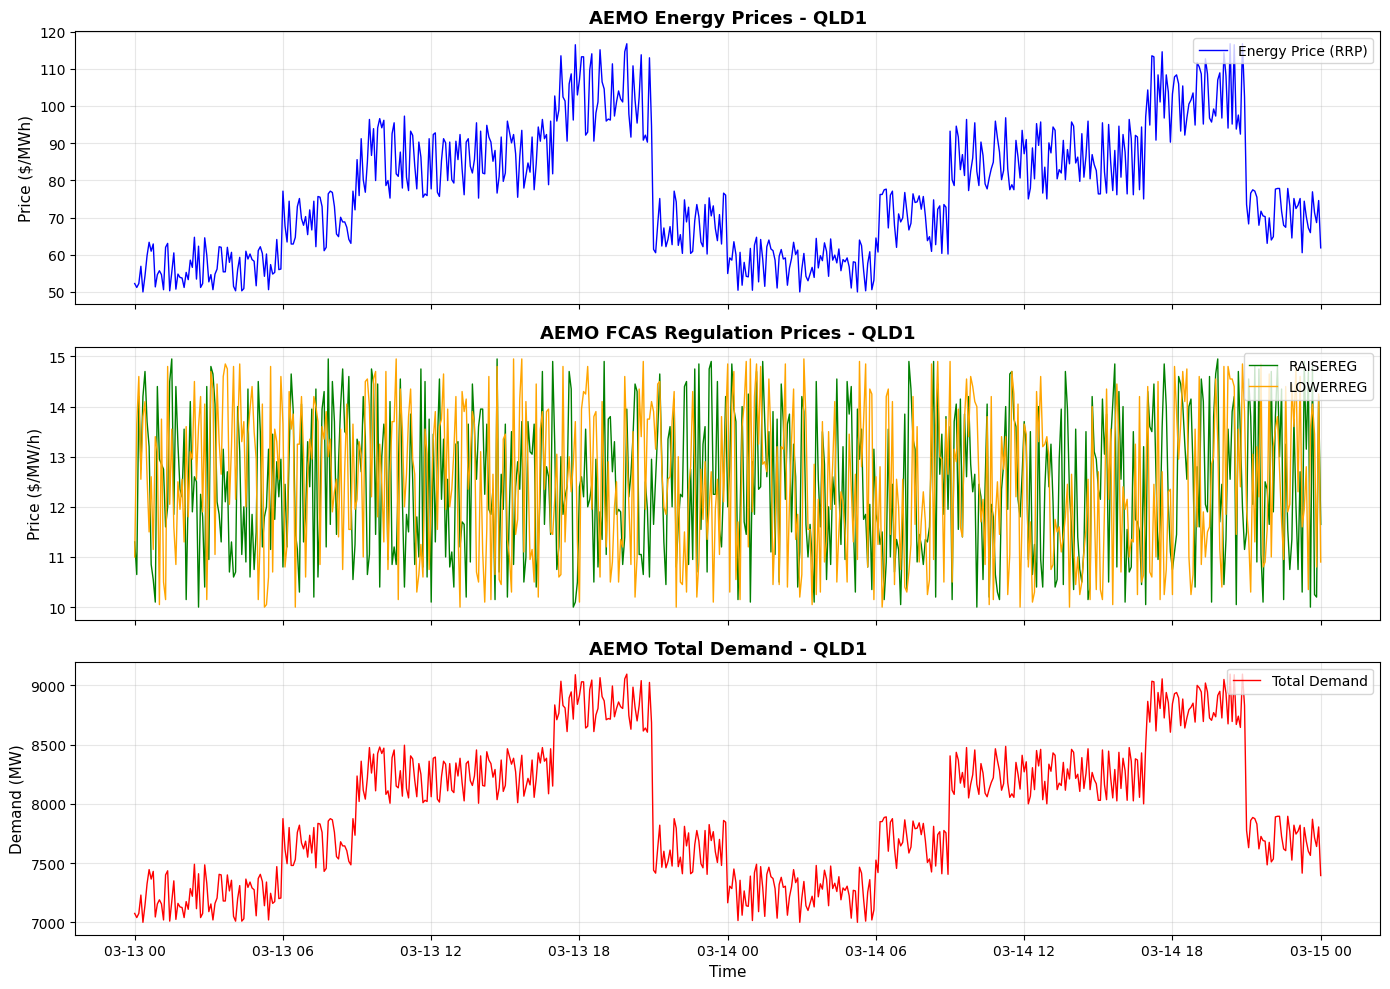


✓ Energy and FCAS price visualization complete


In [8]:
# Convert to pandas for easier plotting
prices_pd = prices.to_pandas()
fcas_raise_pd = fcas_raise.to_pandas()
fcas_lower_pd = fcas_lower.to_pandas()

# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Energy prices
axes[0].plot(prices_pd['SETTLEMENTDATE'], prices_pd['RRP'], label='Energy Price (RRP)', color='blue', linewidth=1)
axes[0].set_ylabel('Price ($/MWh)', fontsize=11)
axes[0].set_title(f'AEMO Energy Prices - {region}', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: FCAS prices
axes[1].plot(fcas_raise_pd['SETTLEMENTDATE'], fcas_raise_pd['PRICE'], label='RAISEREG', color='green', linewidth=1)
axes[1].plot(fcas_lower_pd['SETTLEMENTDATE'], fcas_lower_pd['PRICE'], label='LOWERREG', color='orange', linewidth=1)
axes[1].set_ylabel('Price ($/MW/h)', fontsize=11)
axes[1].set_title(f'AEMO FCAS Regulation Prices - {region}', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Plot 3: Total demand
axes[2].plot(prices_pd['SETTLEMENTDATE'], prices_pd['TOTALDEMAND'], label='Total Demand', color='red', linewidth=1)
axes[2].set_ylabel('Demand (MW)', fontsize=11)
axes[2].set_xlabel('Time', fontsize=11)
axes[2].set_title(f'AEMO Total Demand - {region}', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Energy and FCAS price visualization complete")

## 3. Visualize Solar and Wind Generation

Renewable generation (solar and wind) has distinct patterns:
- **Solar**: Zero at night, peaks around midday
- **Wind**: Variable throughout the day, less predictable than solar

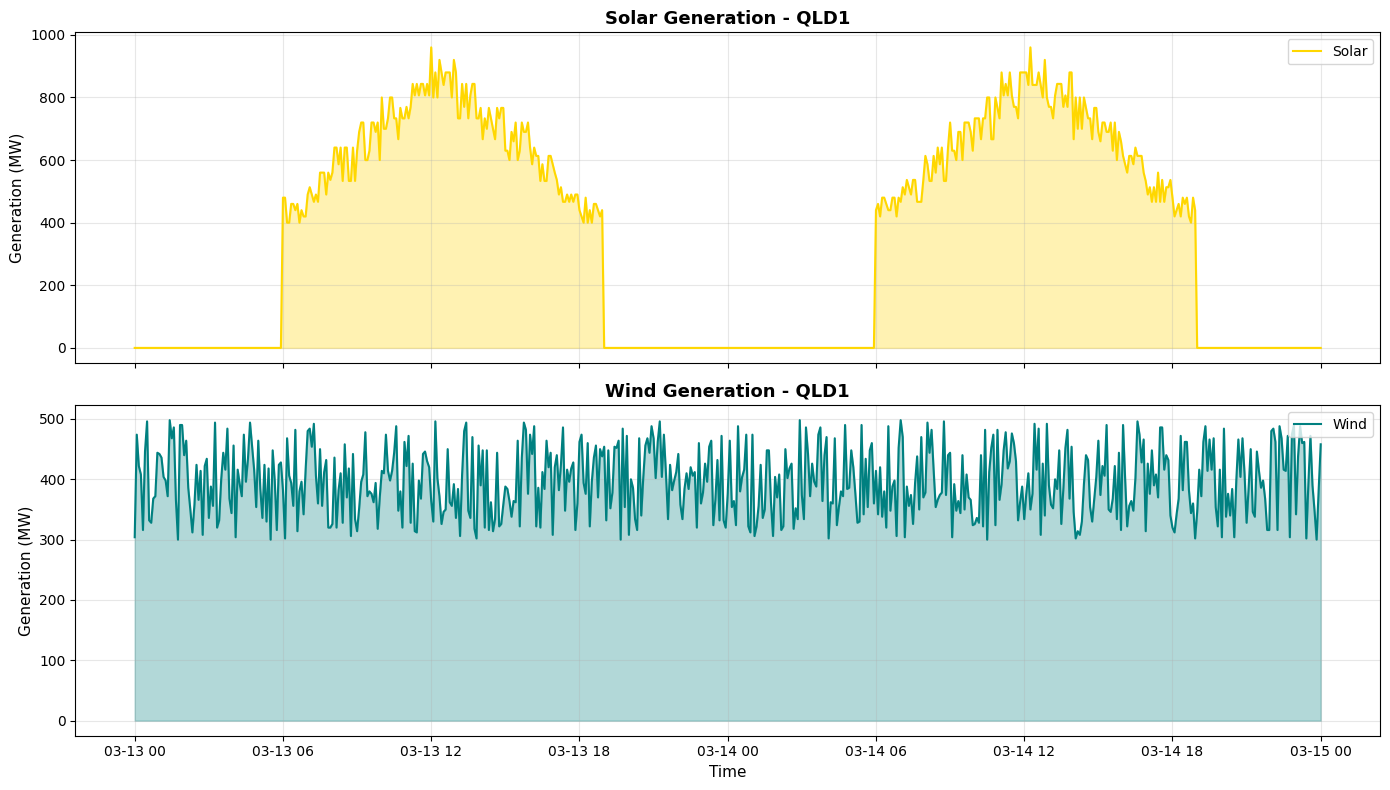


✓ Solar and wind generation visualization complete


In [9]:
# Convert to pandas and pivot for easier plotting
generation_pd = generation.to_pandas()
generation_pivot = generation_pd.pivot(index='SETTLEMENTDATE', columns='FUEL_TYPE', values='GENERATION')

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Solar generation
axes[0].plot(generation_pivot.index, generation_pivot['solar'], label='Solar', color='gold', linewidth=1.5)
axes[0].fill_between(generation_pivot.index, generation_pivot['solar'], alpha=0.3, color='gold')
axes[0].set_ylabel('Generation (MW)', fontsize=11)
axes[0].set_title(f'Solar Generation - {region}', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Wind generation
axes[1].plot(generation_pivot.index, generation_pivot['wind'], label='Wind', color='teal', linewidth=1.5)
axes[1].fill_between(generation_pivot.index, generation_pivot['wind'], alpha=0.3, color='teal')
axes[1].set_ylabel('Generation (MW)', fontsize=11)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_title(f'Wind Generation - {region}', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Solar and wind generation visualization complete")

## 4. Analyze Price-Generation Relationship

High renewable generation typically correlates with lower energy prices.

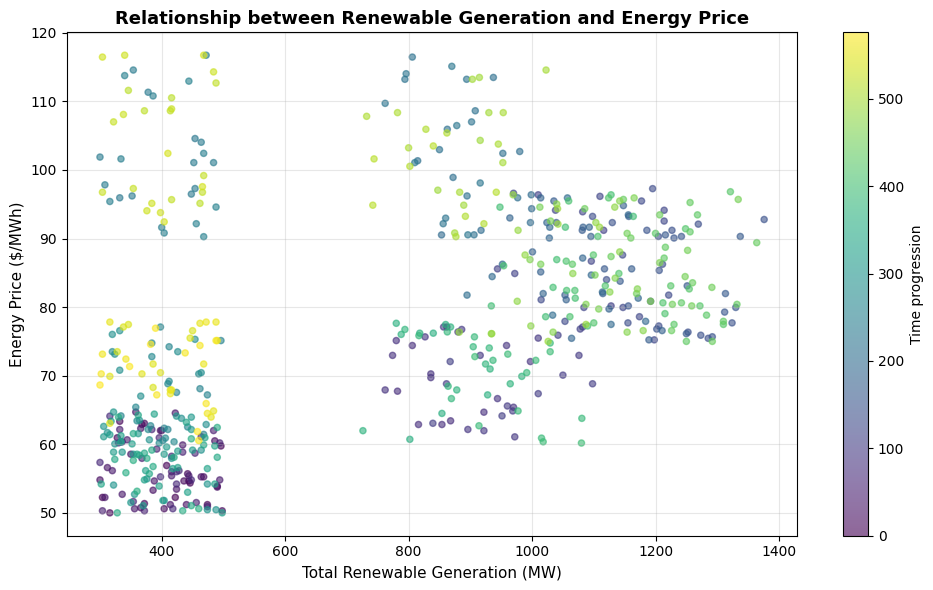


Correlation between renewable generation and price: 0.437
(Negative correlation indicates lower prices with higher renewable generation)


In [10]:
# Combine solar and wind generation
renewable_gen = generation.group_by("SETTLEMENTDATE").agg([
    pl.col("GENERATION").sum().alias("TOTAL_RENEWABLE_MW")
])

# Join with prices
price_gen = prices.join(renewable_gen, on="SETTLEMENTDATE", how="left")

# Convert to pandas for plotting
price_gen_pd = price_gen.to_pandas()

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    price_gen_pd['TOTAL_RENEWABLE_MW'],
    price_gen_pd['RRP'],
    c=price_gen_pd.index,
    cmap='viridis',
    alpha=0.6,
    s=20
)

ax.set_xlabel('Total Renewable Generation (MW)', fontsize=11)
ax.set_ylabel('Energy Price ($/MWh)', fontsize=11)
ax.set_title('Relationship between Renewable Generation and Energy Price', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Time progression')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = price_gen_pd['TOTAL_RENEWABLE_MW'].corr(price_gen_pd['RRP'])
print(f"\nCorrelation between renewable generation and price: {correlation:.3f}")
print("(Negative correlation indicates lower prices with higher renewable generation)")

## 5. Using the Bundle Function

For convenience, you can fetch all data types at once using `fetch_aemo_data_bundle()`.

In [11]:
# Fetch a complete bundle of data
data_bundle = fetch_aemo_data_bundle(
    start_date=start_date,
    end_date=end_date,
    region="NSW1",
    fcas_services=["RAISEREG", "LOWERREG", "RAISE6SEC"],
    fuel_types=["solar", "wind", "coal_black"],
    refresh=False  # Use cached data if available
)

print("\nData bundle contents:")
print(f"  - Prices: {len(data_bundle['prices'])} records")
print(f"  - FCAS: {len(data_bundle['fcas'])} records")
print(f"  - Generation: {len(data_bundle['generation'])} records")

print("\nFCAS services in bundle:")
print(data_bundle['fcas']['SERVICE'].unique())

print("\nFuel types in bundle:")
print(data_bundle['generation']['FUEL_TYPE'].unique())

Fetching AEMO data bundle for NSW1 from 2023-03-13 to 2023-03-15...
Fetching dispatch price data for NSW1 from 2023-03-13 to 2023-03-15...
Cached dispatch price data to data/aemo/dispatch_price_NSW1_2023-03-13_2023-03-15.parquet
Loading cached FCAS price data from data/aemo/fcas_RAISEREG_NSW1_2023-03-13_2023-03-15.parquet
Loading cached FCAS price data from data/aemo/fcas_LOWERREG_NSW1_2023-03-13_2023-03-15.parquet
Fetching FCAS RAISE6SEC price data for NSW1 from 2023-03-13 to 2023-03-15...
Cached FCAS price data to data/aemo/fcas_RAISE6SEC_NSW1_2023-03-13_2023-03-15.parquet
Fetching generation data for ['solar', 'wind', 'coal_black'] in NSW1 from 2023-03-13 to 2023-03-15...
Cached generation data to data/aemo/generation_coal_black_solar_wind_NSW1_2023-03-13_2023-03-15.parquet

Data bundle contents:
  - Prices: 577 records
  - FCAS: 1731 records
  - Generation: 1731 records

FCAS services in bundle:
shape: (3,)
Series: 'SERVICE' [str]
[
	"LOWERREG"
	"RAISEREG"
	"RAISE6SEC"
]

Fuel type

## 6. Summary and Next Steps

This notebook demonstrated:
- ✓ Fetching AEMO energy prices (5-minute dispatch intervals)
- ✓ Fetching FCAS regulation prices
- ✓ Fetching solar and wind generation data
- ✓ Visualizing price and generation patterns
- ✓ Analyzing relationships between renewable generation and prices

### Potential Applications for RL:

1. **Energy Trading Strategy**: Use price forecasts to optimize battery charging/discharging
2. **FCAS Market Participation**: Bid battery capacity into FCAS markets for additional revenue
3. **Renewable Arbitrage**: Charge when solar/wind is high (low prices), discharge during peaks
4. **Multi-Market Optimization**: Balance energy market and FCAS market participation

### Data Quality Considerations:

- Missing data handling (interpolation vs. skipping)
- Price spike detection and handling
- Time zone consistency (AEMO uses Australian Eastern Standard Time)
- Data alignment across different datasets

See `docs/aemo_env_pseudocode.md` for details on integrating this data into a gym environment.